In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))
    
print(f"Project root: {PROJECT_ROOT}")

from baseline import Baseline
from utils import load_audio, save_audio, clip_audio, normalize_audio
from visualize import plot_world_params

Project root: /m/home/home3/37/thieun1/unix/Project/final_project


/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/pyworld/__init__.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2026-04-03 15:29:04.686728: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-03 15:29:04.768915: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDN

In [2]:
# Edit these paths for your files\
source_path = PROJECT_ROOT / 'data' / 'raw' / 'solo_violin' / 'VIII. Double.wav'
target_path = PROJECT_ROOT / "data/raw/voice/FULL/female1/scales/straight/f1_scales_straight_a.wav"

# output_path = 'artifacts/outputs/baseline_transfer.wav'

# Options: 'f0' or 'f0_ap'
method = 'f0_ap'
sample_rate = 16000
normalize_output = True
use_crepe = True  # Whether to use CREPE for f0 estimation (more accurate but slower)

In [3]:
baseline = Baseline(sample_rate=sample_rate)

source_audio, _ = load_audio(source_path, sr=sample_rate, mono=True)
source_audio = clip_audio(source_audio, end_time=18.0, sr=sample_rate)  # Clip to 18 seconds for demo
source_audio = normalize_audio(source_audio)
target_audio, _ = load_audio(target_path, sr=sample_rate, mono=True)
target_audio = normalize_audio(target_audio)

# Baseline methods require source and target to have same length
target_audio, source_audio = baseline.match_length(target_audio, source_audio)

source_audio = source_audio.astype('float64', copy=False)
target_audio = target_audio.astype('float64', copy=False)

if method == 'f0':
    output_audio = baseline.f0_transfer(target_audio, source_audio, use_crepe=use_crepe)
elif method == 'f0_ap':
    output_audio = baseline.f0_and_ap_transfer(target_audio, source_audio, use_crepe=use_crepe)
else:
    raise ValueError("method must be 'f0' or 'f0_ap'")

# save_audio(output_path, output_audio, sample_rate, normalize=normalize_output)
# print(f'Saved output to: {output_path}')

2026-04-03 15:29:58.775058: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-03 15:29:58.828843: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-03 15:29:58.830929: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-04-03 15:29:58.833270: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuil

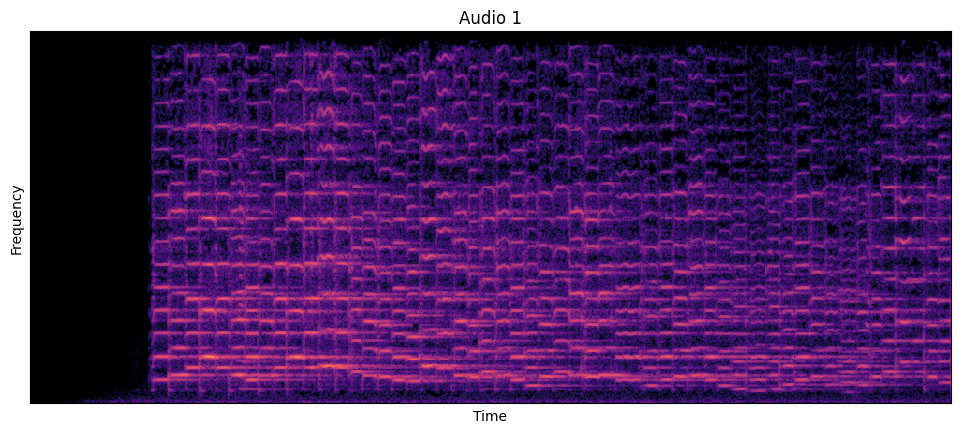

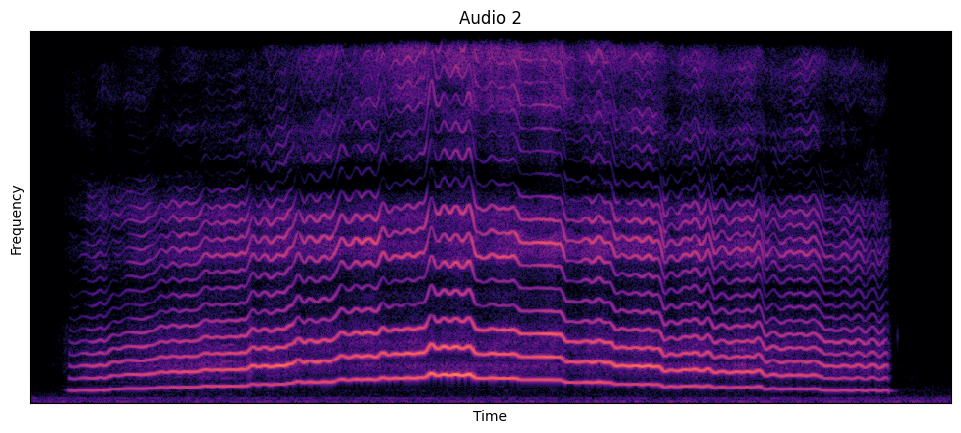

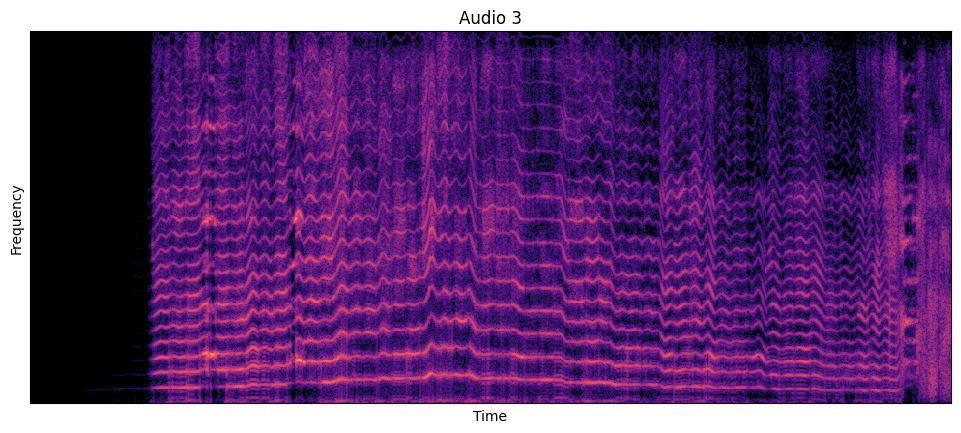

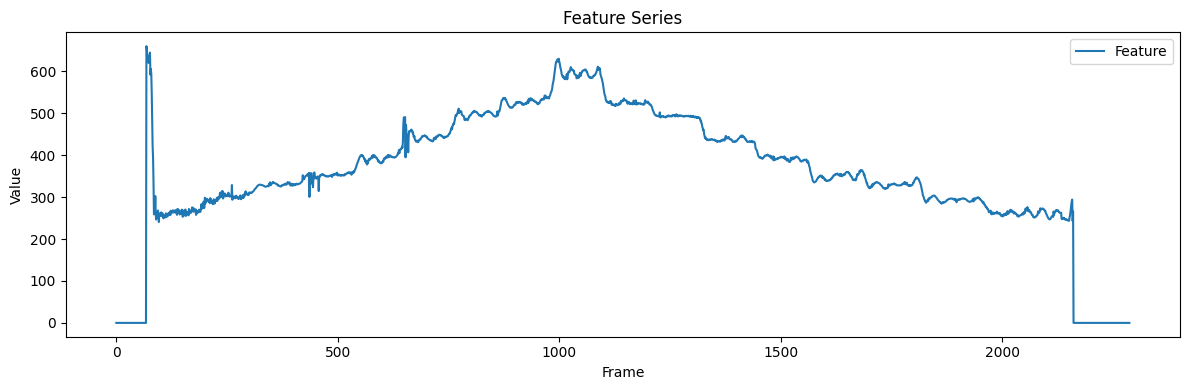

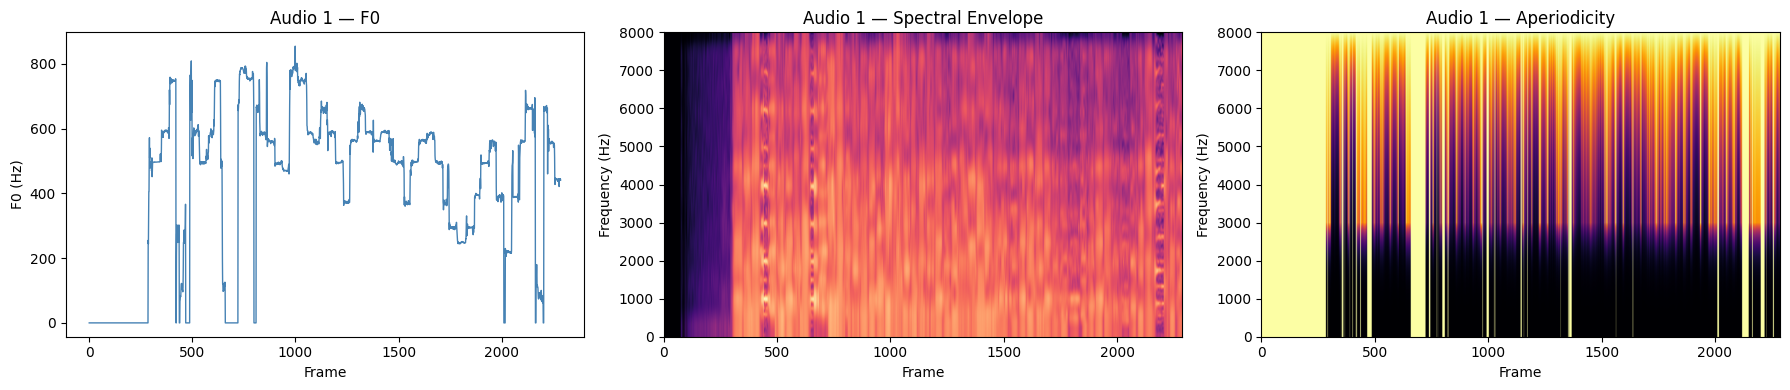

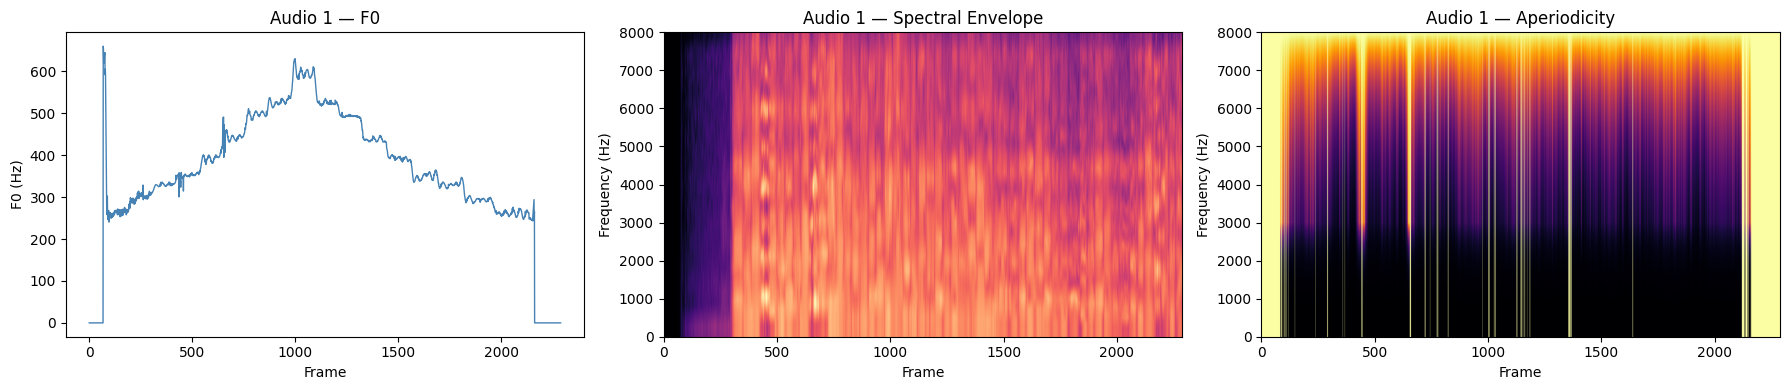

In [4]:
from visualize import plot_spectrograms,plot_series

# Plot source, target, and generated output spectrograms
plot_spectrograms(
    [source_audio, target_audio, output_audio],
    sr=sample_rate,
)

plot_series(baseline.decompose(output_audio)[0])
plot_world_params(*baseline.decompose(source_audio))
plot_world_params(*baseline.decompose(output_audio))

In [5]:
from IPython.display import Audio, display, Markdown

display(Markdown("### Source Audio"))
display(Audio(source_audio, rate=sample_rate))

display(Markdown("### Target Audio"))
display(Audio(target_audio, rate=sample_rate))

display(Markdown(f"### Output Audio (method: `{method}`)"))
display(Audio(output_audio, rate=sample_rate))

### Source Audio

### Target Audio

### Output Audio (method: `f0_ap`)